In [32]:
from IPython.display import HTML

HTML("""
<style>

a[href^="http://"],
a[href^="https://"] {
    color: blue !important;
}

/* stil za sve tabele */
table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important;
    max-width: none !important;
    table-layout: auto !important;
    border-collapse: collapse !important;
    font-family: "Segoe UI", "Calibri", sans-serif !important;
    font-size: 12px !important;
}

th, td {
    padding: 8px 20px !important;
}

/* дебља, јача линија испод заглавља */
tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* тања, светлија линија испод последњег реда */
tr:last-child td {
    border-bottom: 1px solid #aaa !important;
}

</style>
""")


# Monte Karlo simulacije

**Šta su Monte Karlo simulacije?**

Monte Karlo simulacija, takođe poznata kao Monte Karlo metoda ili simulacija višestruke verovatnoće, je matematička tehnika koja se koristi za procenu mogućih ishoda neizvesnog događaja. Metodu Monte Karla izmislili su Džon fon Nojman i Stanislav Ulam tokom Drugog svetskog rata da bi poboljšali donošenje odluka u neizvesnim uslovima. Ime je dobio po poznatom kazino gradu, zvanom Monte Karlo, pošto je element slučajnosti jezgro modela modela, slično u igri rulet.

Od svog uvođenja, Monte Karlo metod je procenio uticaj rizika u mnogim scenarijima iz stvarnog života, kao što su veštačka inteligencija, cene akcija, predviđanje prodaje, upravljanje projektima i određivanje cena. On takođe pruža brojne prednosti u odnosu na prediktivne modele sa fiksnim ulazima, kao što je mogućnost sprovođenja analize osetljivosti ili izračunavanja korelacije inputa. Analiza osetljivosti omogućava donosiocima odluka da vide uticaj pojedinačnih inputa na dati ishod, a korelacija im omogućava da razumeju odnose između bilo koje ulazne promenljive.

**Kako funkcioniše metod Monte Karlo?** Za razliku od klasičnog modela predviđanja, gde imamo fiksirane ulazne vrednosti, Monte Karlo simulacija predviđa skup ishoda na osnovu vrednosti čija je karakteristika slučajnost. Drugim rečima, Monte Karlo simulacija gradi model mogućih rezultata korišćenjem raspodele verovatnoća, kao što je uniformna ili normalna raspodela, za bilo koju promenljivu koja ima inherentnu nesigurnost. Zatim ponovo i iznova izračunava rezultate, svaki put koristeći drugačiji skup slučajnih brojeva iz istih raspodela verovatnoća. U tipičnom Monte Karlo eksperimentu, ova vežba se može ponoviti hiljade puta da bi se proizveo veliki broj verovatnih ishoda.

Monte Karlo simulacije se takođe koriste za dugoročna predviđanja zbog svoje tačnosti. Kako se broj ulaznih podataka povećava, raste i broj predviđanja, što vam omogućava da projektujete rezultate dalje u vremenu sa više tačnosti. Kada je Monte Karlo simulacija završena, ona daje raspodelu verovatnoća nad skupom ishoda.

**Koji su osnovni koraci u primeni Monte Karlo metoda?**  Bez obzira koji alat se koristi, Monte Karlo tehnika uključuja tri osnovna koraka:

- Postavite prediktivni model, identifikujući i zavisnu promenljivu koju treba predvideti i nezavisne promenljive (poznate i kao promenljive ulaza, rizika ili prediktora) koje će pokretati predviđanje.
- Odredite raspodele verovatnoća nezavisnih promenljivih. Koristite istorijske podatke i/ili subjektivnu procenu analitičara da biste definisali opseg verovatnih vrednosti i dodelili pondere verovatnoće za svaku.
- Pokrenite simulacije više puta, generišući nasumične vrednosti nezavisnih promenljivih. Uradite ovo dok se ne prikupi dovoljno rezultata da se napravi reprezentativan uzorak skoro beskonačnog broja mogućih kombinacija.

Možete pokrenuti onoliko Monte Karlo simulacija koliko želite tako što ćete modifikovati osnovne parametre koje koristite za simulaciju podataka. Međutim, takođe ćete želeti da izračunate opseg varijacije unutar uzorka tako što ćete izračunati varijansu i standardnu devijaciju, koje se obično koriste kao mere varijacije podataka. Obično se manja varijacija smatra boljom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

```{admonition} Primer 1. *Bacanje 3 kocke*
:class: tip

Bacamo tri kockice za igru i posmatramo ukupan zbir tačkica na gornjim stranama sve tri kocke. Odrediti raspodelu verovatnoća brojeva koji se mogu pojaviti kao zbir.
```

Prvo ćemo konstruisati funkciju koja simulira jedno bacanje.

In [8]:
def bacanje_3k():
    return np.random.randint(1,7)+np.random.randint(1,7)+np.random.randint(1,7)

Testirajmo sada funkciju koja simulira jedno bacanje:

In [11]:
for i in range(25):
    print(bacanje_3k(),end='  ')    

9  17  7  10  9  10  16  13  11  9  11  8  16  10  10  7  7  11  12  11  11  13  10  12  8  

Sad kreirajmo slučajni uzorak obima $n=10,000$

In [14]:
n=10**5
simulacije = [bacanje_3k() for i in range(n)]

Kreirajmo DataFrame objekat koji sadrži simulacije kako bi lakše napravili analizu (imamo više metoda).

In [16]:
df=pd.DataFrame(simulacije)

In [18]:
raspodela_3k = df.value_counts(sort = False, normalize =True)

In [20]:
raspodela_3k = pd.DataFrame({'Verovatnoća': raspodela_3k.values}, index=range(3,19))
raspodela_3k.index.rename('Zbir', inplace = True)

Raspodela verovatnoća nad mogućim zbirovima je sada:

In [20]:
print(raspodela_3k)

      Verovatnoća
Zbir             
3         0.00482
4         0.01370
5         0.02696
6         0.04565
7         0.06959
8         0.09817
9         0.11460
10        0.12515
11        0.12511
12        0.11666
13        0.09575
14        0.06960
15        0.04659
16        0.02874
17        0.01395
18        0.00496


In [ ]:
Na kraju, možemo raspodelu prikazati i grafički stubičastim dijagramom:

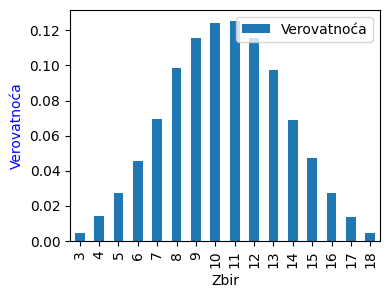

In [23]:
fig, ax1 = plt.subplots(figsize=(4,3))
ax1.set_ylabel('Verovatnoća', color='blue')
ax1.set_xlabel('Zbir')
raspodela_3k.plot.bar(ax=ax1)
plt.show()

```{admonition} Primer 2. *Aukcija*
:class: tip

Osoba A vrednuje antikvarni predmet 110 (u hiljadama dolara). Pored osobe A na aukciji učestvuju još osobe B i C. Vrednost koju osoba B dodeljuje predmetu aukcije je slučajna veličina sa diskretnom uniformnom raspodelom na intervalu od 90 do 115, a  vrednost koju osoba C dodeljuje predmetu aukcije je slučajna veličina sa diskretnom uniformnom raspodelom na intervalu od 80  do 115. Pretpostavimo da na aukciji predmet dobija osoba koja ponudi najvišu cenu  i da onda plaća za predmet drugu najvišu cenu.

- Napravite simulacije aukcije i odredite očekivani profit osobe A, kao i standardnu devijaciju tog profita, ako je osoba odlučila da licitira 110. 
- Pretpostavite sada da osoba A razmatra redom licitacije od 80 do 115 (samo iznose u celim brojevima). Odredite optimalnu strategiju, primenom simulacija, ako je kriterijum očekivani profit. 

**Konstrukcija modela.**

Sledeća funkcija simulira jednu aukciju:

In [25]:
def aukcija(b_0= 100, v_0=110, a_1=90, b_1=115, a_2=80, b_2=115):
    """
    Funkcija simulira jednu aukciju po drugoj najvišoj ceni sa tri učesnika iz aspekta prvog učesnika.
    Promenljive:
    b_0 - koliko će osoba A licitirati
    v_0 - koliko osoba A vrednuje predmet
    a_1, b_1 - parametri raspodele (uniformne) vezani za osobu B
    a_2, b_2 - parametri raspodele (uniformne) vezani za osobu C
    """
    
    licitacije=[b_0]                                        # licitacija A
    licitacije.append(np.random.uniform(a_1,b_1))           # Licitacija B
    licitacije.append(np.random.uniform(a_2,b_2))           # Licitacija C 
    if sorted(licitacije, reverse=True)[0]==licitacije[0]:        # Da li je pobednik aukcije A?
        return round(v_0 - sorted(licitacije, reverse=True)[1],2) # Ako jeste koliko je njegov dobitak ?
    else:
        return 0                                                    

Testirajmo sada našu funkciju:

In [28]:
for i in range(10):
    print(aukcija(), end='  ')

0  0  0  0  10.04  0  0  0  0  0  

Simulirajmo aukciju veliki broj puta.

In [30]:
n=10**5
simulacije = pd.Series([aukcija() for i in range(n)])

**Analiza dobijenih rezultata**

In [33]:
print(f'Aritmetička sredina: {simulacije.mean():.2f}')
print(f'Standardna devijacija: {simulacije.std():.2f}')

Aritmetička sredina: 3.25
Standardna devijacija: 6.10


Prikažimo rezultate histogramom:

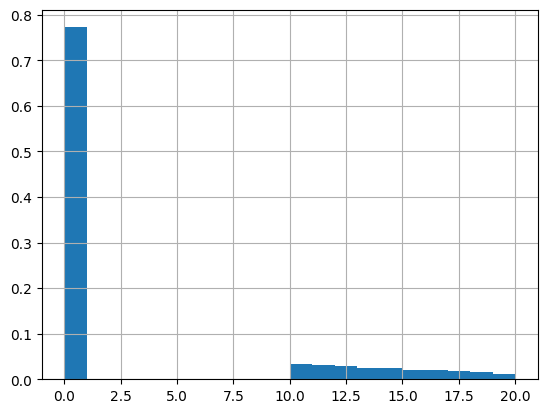

In [24]:
simulacije.hist(bins=20, density=True);

Da li odavde možemo nešto da zaklučimo? Skoro ništa, sem da je očekivani dobitak relativno skroman i sa relativno veliko varijansom.

Povodom toga možemo da pokrenemo drugi element simulacija, a to je analiza osetljivosti. U tom smislu, variraćemo moguće licite prve osobe u rasponu od 80 do 115 (takve licitacije imaju smisla s obzirom na raspodele drugih učesnika) i ocenjivaćemo ih sa srednjim dobitkom.

In [28]:
n=10**5
akcije =[np.array([aukcija(bid) for i in range(n)]).mean() for bid in range(80,116)] 

Pogledajmo sada stubičasti dijagram ocena licita:

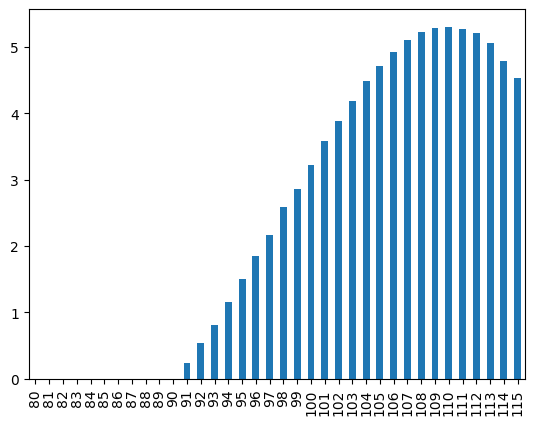

In [29]:
akcije=pd.Series(akcije, index=np.arange(80,116))
akcije.plot.bar();

Ako nas interesuje najbolja akcija u tom smislu:

In [34]:
print(f'Najbolji licit je {80+akcije.argmax()}.')

Najbolji licit je 110


Rezultat je se poklapa sa onim što kaže teorija u slučaju uniformnih raspodela ostalih aukcionara, a to je da je najbolja straegija onoliko koliko vrednujemo predmet. Prednost simulacija je to što možemo koristiti i druge raspodele za koje teorija ne daje optimalan licit.

```{admonition} Primer 3. *Sezonski kalendari* 
:class: tip

Izdavačka kuća planira štampanje sezonskih kalendara za predstojeću godinu. Potražnja za kalendarima je neizvesna i može se opisati diskretnom slučajnom promenljivom sa raspodelom verovatnoća prikazanom u tabeli.

:::{table} Raspodela verovatnoća potražnje
:class: thin
:label: sim_p4
:align: center

| Potražnja     | $5\,000$ | $8\,000$ | $12\,000$ | $15\,000$ |
|:--------------|:--------:|:--------:|:---------:|:---------:|
| Verovatnoća   | $0.20$   | $0.30$   | $0.35$    | $0.15$    |
:::

Prodajna cena jednog kalendara iznosi 6 €, dok su varijabilni troškovi štampanja 2.5 € po primerku. Neprodati kalendari se nakon sezone recikliraju, pri čemu trošak reciklaže iznosi 0.4 € po komadu.

Odrediti optimalnu količinu kalendara koju treba odštampati.


**Konstrukcija modela.**

Prvo ćemo konstruisati funkciju koja računa profit za fiksirane vrednosti parametara.

In [2]:
def profit(s, d, p = 6, vc = 2.5, c= 0.4):
    """
    Funkcija računa profit u zavisnosti od tražnje i nabavne količine
    
    Promenljive:
    p - prodajna cena čestittki
    vc - varijablini troškovi proizvodnje
    c - troškovi reciklaže
    s - ponuda
    d - tražnja (Slučajna promenljiva)
    """
    
    if s < d:
        profit = s*p - s*vc
    else:
        profit = d*p - s*vc - (s-d)*c
    return profit

In [4]:
# Testiranje 1
profit(12000, 8000) 

16400.0

In [5]:
# Testiranje 2
profit(8000, 12000) 

28000.0

**Generisanje uzorka i vrednosti za ispitivanje osetljivosti.**

In [7]:
traznja = np.random.choice([5000, 8000, 12000, 15000], size=10000, replace=True, p=[0.2, 0.3, 0.35, 0.15]) # uzorak

In [6]:
ponuda = [5000, 8000, 12000, 15000] # Vrednosti ponude za testiranje osetljivosti

In [8]:
profit_multi = [ [profit(s, d) for s in ponuda] for d in traznja]
df_profit = pd.DataFrame(profit_multi, columns=['p_5000', 'p_8000', 'p_12000', 'p_15000'])
df_profit.head()

,p_5000,p_8000,p_12000,p_15000
0,17500.0,28000.0,16400.0,7700.0
1,17500.0,28000.0,16400.0,7700.0
2,17500.0,28000.0,42000.0,52500.0
3,17500.0,8800.0,-2800.0,-11500.0
4,17500.0,28000.0,16400.0,7700.0


**Analiza rezultata.**

In [11]:
df_profit.describe().round(2)

,p_5000,p_8000,p_12000,p_15000
count,10000.0,10000.00,10000.00,10000.00
mean,17500.0,24198.40,25472.64,19679.52
std,0.0,7651.43,17896.66,21534.93
min,17500.0,8800.00,-2800.00,-11500.00
25%,17500.0,28000.00,16400.00,7700.00
50%,17500.0,28000.00,42000.00,33300.00
75%,17500.0,28000.00,42000.00,33300.00
max,17500.0,28000.00,42000.00,52500.00


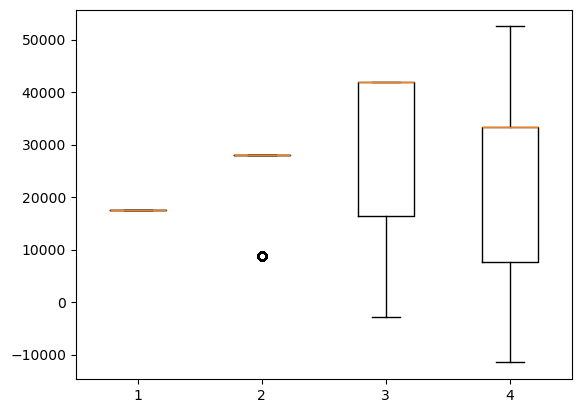

In [10]:
plt.boxplot(df_profit)
plt.show()

**Zaključak.**
Zavisi od rizika: 
- veća sklonost riziku  ... štampanje 12000
- manja sklonost riziku  ... štampanje 8000

```{admonition} Primer 3. *Senzori* 
:class: tip

*AeroSense* je kompanija koja razvija senzorske sisteme za kontrolu kvaliteta vazduha u industrijskim pogonima. Nakon nekoliko incidenata u lokalnim fabrikama, tim *AeroSense*-a je napravio prototip uređaja koji u realnom vremenu detektuje opasne gasove i automatski šalje upozorenja službama bezbednosti. Rešenje je tehnički inovativno i ima potencijal da brzo osvoji deo tržišta.

Menadžment želi da proceni raspodelu profita u prvoj godini poslovanja. Zbog ograničene gotovine, posebno ih zanima rizik od gubitka. Kao ključne faktore profita identifikovali su: prodajnu cenu po jedinici ($p$), fiksne administrativne i marketinške troškove u prvoj godini ($c_a$), troškove montaže po jedinici ($c_m$), troškove komponenti po jedinici ($c_k$) i godišnju tražnju ($d$).

Na osnovu analize tržišta procenjeno je da će prodajna cena biti $p=319\$$ po jedinici, a da će ukupni administrativni i marketinški troškovi u prvoj godini iznositi $c_a=1\,350\,000\$$. Međutim, *AeroSense* nije siguran u troškove montaže, troškove komponenti i obim tražnje.

Napraviti Monte Karlo simulaciju za problem *AeroSense*-a pod sledećim pretpostavkama:

- Troškovi montaže po jedinici ($c_m$) su diskretna slučajna promenljiva sa raspodelom  
  $$
  c_m:\begin{pmatrix}
  52 & 54 & 56 & 58 & 60 \\
  0.15 & 0.25 & 0.30 & 0.20 & 0.10
  \end{pmatrix}
  $$
- Troškovi komponenti po jedinici ($c_k$) su slučajna promenljiva sa raspodelom: $\mathcal{U}(95,120)$
- Godišnja tražnja ($d$) je slučajna promenljiva sa raspodelom: $\mathcal{N}(18\,000,5\,200)$
```

**Model.**

In [18]:
def senzori(c_m, c_k, d, p = 319, c_a = 1350000):
    """
    Funkcija računa profit u zavisnosti od cena rada po jedinici, troškova delova po jedinici i tražnje
    
    Promenljive:
    p - prodajna cena 
    c_a - administrativni troškovi i troškovi reklamiranja
    c_m - troškovi montaže po jedinici
    c_k - troškovi komponenti po jedinici
    d - tražnja
    """
    
    # Prihod
    R = d*p
    # Fiksni troškovi
    FC = c_a 
    #Varijablini troškovi
    VC = d*(c_k+c_m)
    
    #Profit
    P = R-VC-FC
    return P

#### Testiranje

In [19]:
senzori(60,100,15000)

1035000

**Simulacije.**

In [20]:
n = 10000 # Veličina uzorka
c_m = np.random.choice(np.arange(52,62,2), size=n, replace=True, p=[0.15, 0.25, 0.3, 0.2, 0.1])
c_k = np.random.uniform(95,120, size =n)
d   = np.random.normal(18000,5200, size=n)

In [22]:
df_senzori_profit = pd.Series(sanatronics(c_m, c_k, d))

**Analiza rezultata.**

In [24]:
df_senzori_profit.describe()

count    1.000000e+04
mean     1.450151e+06
std      8.256111e+05
min     -1.872444e+06
25%      8.898350e+05
50%      1.439641e+06
75%      2.002317e+06
max      4.990693e+06
dtype: float64

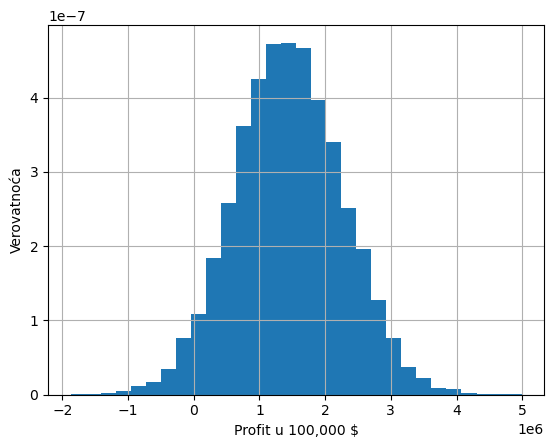

In [27]:
fig, ax = plt.subplots()
df_senzori_profit.hist(ax=ax, bins=30, density=True)
plt.ylabel("Verovatnoća")
plt.xlabel("Profit u 100,000 $")
plt.show()

In [28]:
np.count_nonzero(df_senzori_profit<0)/n  #Verovatnoća da će profit biti manji od nule

np.float64(0.0377)

### Zaključak

Očekivani profit od preko 1,450,000$\$$ i jako mala verovatnoća gubitka sugerišu ulazak u posao.

<style>

/* bold i veći brojevi */
.text_cell_render ol > li::marker {
  font-weight: 900;
  font-size: 1.7em;
}

/* VELIKI razmak između zadataka */
.text_cell_render ol > li {
  margin-top: 2.8em !important;
  margin-bottom: 2.8em !important;
  line-height: 1.45 !important;
}

/* PODLISTA — kompresovana */
.text_cell_render ol > li > ul > li {
  margin-top: 0 !important;
  margin-bottom: 0 !important;
  line-height: 0.95 !important;
}

</style>

## Zadaci i problemi


:::{admonition} Zadatak 1
:class: tip 

Kompanija Trayal u svrhu promocije nudi 1 evro za svakih započetih 100 kilometara ako životni vek nove gume bude ispod 30,000 kilometara. Menadžment kompanije veruje da je životni vek najnovije gume slučajna promenljiva raspodelom $\mathcal N (35000,5000^2)$. Primer: Neka je guma prešla 29356 kilometara. Kako je $30000-29356=644$, kompanija će nadoknaditi 7 evra.
- Koliki su prosečni troškovi ove promocije po jednoj gumi?  
- Kolika je verovatnoća da će trošak promocije po jednoj gumi biti preko 50 evra?
:::

:::{admonition} Zadatak 2
:class: tip 

Konstruišite simulacioni model koji generiše uzorak veličine 1000 iz normalne raspodele $\mathcal{N}(5, 2)$. Na osnovu prethodnog uzorka konstruišite histogram sa 12 stubića.
:::

:::{admonition} Zadatak 3
:class: tip 

Pretpostavi da je kvartalni rast realnog BDP-a dat kao $ g_t = \mu + \varepsilon_t $, gde je $\mu=0.6\%$ po kvartalu, a $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ sa $\sigma=0.8\%$.

- Simuliraj 10.000 puteva rasta za 4 kvartala i izračunaj godišnji rast kao $ \left(\prod_{t=1}^4 \left(1+\frac{g_t}{100}\right) - 1\right) \cdot 100 $.  
- Prikaži prosečan godišnji rast.
:::

:::{admonition} Zadatak 4
:class: tip 

Zaposleni u MTS-u dobijaju zdravstveno osiguranje kroz grupni plan koji izdaje Dunav. Tokom protekle godine 40 odsto zaposlenih nije podnelo nijedan zahtev za zdravstveno osiguranje, 40 odsto je podnelo samo mali zahtev, a 20 odsto veći. Mala potraživanja su bila ravnomerno raspoređena između 0 i 500 evra, dok su velika potraživanja bila ravnomerno raspoređena između 500 i 2.000 evra.

Na osnovu ovog iskustva, Dunav sada pregovara o plaćanju premija korporacije po zaposlenom za narednu godinu. Vi ste analitičar  za osiguravajuće društvo i dodeljen vam je zadatak da procenite prosečnu cenu osiguranja za zaposlene u korporaciji.
:::

:::{admonition} Zadatak 5
:class: tip 

Kompanija **FitCloud** razvila je mobilnu aplikaciju za praćenje fizičke aktivnosti. Aplikacija je besplatna, ali deo korisnika prelazi na **premium plan**, čime ostvaruje prihod.  
Menadžment želi da proceni kretanje broja korisnika i prihoda tokom narednih 12 meseci.

Tvoj zadatak je da napišeš program koji će **simulirati rast korisnika i mesečni prihod** odaplikacije, koristeći jednostavan probabilistički model.

Pravila i pretpostavke modela

- Početni broj korisnika: `U0`  
- Svakog meseca aplikacija dobija nove korisnike (`new_users`) nasumično između **min_new** i **max_new**.  
- Deo korisnika prelazi na **premium plan** sa verovatnoćom `p_premium`.  
- Mesečni prihod se računa po formuli:  `prihod = premium_users * avg_revenue_per_user`  
- Deo korisnika mesečno napušta aplikaciju (**churn**) sa verovatnoćom `p_churn`.  
- Simulacija traje 12 meseci (ili `months` ako se navede druga vrednost).

Napisati funkciju:

```python
def fitcloud_simulation(U0, min_new, max_new, p_premium, p_churn, avg_revenue_per_user, months=12):
    """
    Simulira rast korisnika i prihod aplikacije tokom 'months' meseci.
    Vraća listu tuple-ova:
    [(mesec, ukupno_korisnika, premium_korisnici, prihod_usd), ...]
    """
:::

:::{admonition} Zadatak 6
:class: tip 

Neka slučajna promenljiva $X$ reprezentuje jedan događaj osiguranog gubitka (izražen novčanim iznosom). Prirodno, pretpostavljamo da je $X>0$. Slučajna promenljiva $Y$ reprezentuje iznos odštete ili ceo gubitak. Uobičajeno je da u slučajevima garancije i osiguranja $Y$ bude striktno manje od $X$, kako bi osigurana osoba delila rizik gubitka  sa osiguravačem. To se postiže franšizom. 

Franšiza *ograničavajući prag* je vrednost, u oznaci $u$, koja se isplaćuje ukoliko gubitak premaši tu vrednost. Ako se pređe ograničavajući prag (odnosno $X>u$), tada je iznos odštete $Y=u$, u suprotnom je jednak $X$. Primeri: Neka je $u = 50$. Ako je $X=40$, tada $Y=40$; ako je $X=400$, tada $Y=50=\min(X,50)$

Napraviti simulacioni model koji će rešiti sledeći zadatak: 

Zdravstvena  organizacija za izdržavanje i čuvanje bolesnih osoba trenutno plaća pune troškove korišćenja sobe za hitne slučajeve svim svojim klijentima. Kompanija procenjuje moguće uštede koje bi mogle da rezultiraju uvođenjem ograničavajućeg praga od 2000 po poseti sobe za hitne slučajeve koji bi se primenjivao na sve klijente. Pretpostavimo da su troškovi posete sobe za hitne slučajeve eksponencijalno raspoređeni sa srednjom vrednošću od 1000. Za koliko procenta se mogu očekivati uštede?

Uputstvo: 
- Kod eksponencijalne raspodele, $X:\mathcal{E}(\lambda)$, važi: $E(X)=\lambda$ i $f(x;\lambda)=\begin{cases} \frac1\lambda e^{-\frac1\lambda x}, & x\ge 0 \\ 0, &x<0\end{cases}$  
- Uzorak iz eksponencijalne raspodele dobija se pozivom funkcije `random.exponential` iz modula numpy.
:::

:::{admonition} Zadatak 7
:class: tip 

Kazino je igračima omogućio igranje nove igre. Pored uobičajenih igara (blek džek, rulet, itd.) nude igru sa sledećim pravilima:

- Svaki potez u igri uključuje uzastopno bacanje nepristrasnog novčića sve dok razlika između broja bačenih glava i broja pisama ne bude 3.
- Ako odlučite da igrate igru, od vas se traži da platite 1 dolar za svako bacanje novčića. Nije vam dozvoljeno da odustanete tokom igranja igre.
- Dobijate 8 dolara na kraju svake igre.

Dakle, dobijate novac ako je potreban broj bacanja manji od 8, i gubite novac ako je potrebno više od 8 bacanja. Evo nekoliko primera (gde $G$ označava glavu i $P$ označava pismo):

```{table} 
:align: center
:header-rows: 1

| Događaj | Broj bacanja | Dobitak |
| :-     |      :-:     |  -:    | 
| GGG      |  3           |  5\$ | 
| PGPPP    |  5           |  3\$ |  
| PGGPGPGPPPP | 11 | -3\$ |
```
Da li ćete igrati ovu igru?

:::

:::{admonition} Zadatak 8
:class: tip 

Konstruišite simulacioni model koji generiše uzorak veličine 1000 iz uniformne raspodele $\mathcal{U}(0,1)$. Na osnovu tog uzorka, konstrišite uzorak koji pripada raspodeli $\mathcal{U}^4(0,1).$   

Ako je $X$ prva cifra u podatku iz $\mathcal{U}^4(0,1)$  proverite da li $X$ zadovoljava Benfordovu raspodelu, odnosno:
$$\begin{equation*} P\{X=d\}=\log(1+\frac1d)\text{, gde je}\,\, d\in\{1, 2, \ldots, 8,9\} \end{equation*}$$

:::  

:::{admonition} Zadatak 9
:class: tip 

Pretpostavimo da cena akcije određene kompanije koja se kotira na njujorškoj berzi trenutno iznosi 39 dolara. Sledeća raspodela verovatnoće pokazuje procenu promenu cena po akciji u periodu od tri meseca:

|Promena cene | Verovatnoća|
|:---------:|:----------:|
|-3 | 0.05|
|-2 | 0.1|
|0 | 0.25|
|1 | 0.2|
| 2 | 0.2|
|3 | 0.1|
|4 | 0.1|

Konstruišite simulacioni model koji izračunava vrednost cene akcija za 3 meseca.
:::

:::{admonition} Zadatak 10
:class: tip 

Osoba A i osoba B igraju igru u kojoj osoba A pobeđuje sa verovatnoćom 0,1. Budžet osobe A u igri je 10000\$, a osobe B 100\$. U svakoj igri osobe ulažu *all in* (sav novac) u pot, a pobednik dobija minimalan ulog u pot pomnožen sa 2. Na primer, ako jedan jedan igrač ima 300\$, a drugi 9800\$, tada pobednik dobija 600\$.

- Napravite funkciju koja simulira jednu igru. Ulazne parametre i izlazne parametre osmislite sami. Testirajte funkciju.

- Sad zamislite da igrači ponavljaju ovu igru sve dok jedan ne izgubi sav novac. Napravite Monte Karlo simulacije kako bi odredili da odredili očekivani dobitak prvog igrača.

:::

:::{admonition} Zadatak 11
:class: tip 

Knjižara drži na zalihama jedan naslov knjige. Dnevna tražnja je slučajna veličina sa sledećom diskretnom raspodelom:

<table style="width: 60%; margin: auto;">
  <tr>
    <th>Tražnja</th><th>0</th><th>1</th><th>2</th><th>3</th><th>4</th>
  </tr>
  <tr>
    <td>Verovatnoća </td><td>0.05</td><td>0.10</td><td>0.30</td><td>0.45</td><td>0.10</td>
  </tr>
</table>

Vreme isporuke (lead time) za dopunu zaliha iznosi 1 dan.
Trošak naručivanja iznosi 10 dinara po narudžbini.  
Trošak držanja zaliha iznosi 0.5 dinara po knjizi dnevno i računa se na osnovu stanja zaliha na kraju dana.

Razmatraju se dve politike upravljanja zalihama:

A) Naručiti 5 knjiga kada (trenutna zaliha + neisporučene narudžbine) padne ispod 8 knjiga.  
B) Naručiti 8 knjiga kada (trenutna zaliha + neisporučene narudžbine) padne ispod 8 knjiga.

Na početku prvog dana knjižara ima 8 knjiga na lageru i nema neisporučenih narudžbina.

Za svaki dan simulacije važi sledeći redosled:
- Na početku dana stižu sve narudžbine naručene prethodnog dana.
- Realizuje se dnevna tražnja.
- Ako je tražnja veća od raspoložive zalihe, prodaje se koliko ima, a ostatak tražnje se gubi (lost sales).
- Na kraju dana obračunava se trošak držanja zaliha.
- Nakon toga se proverava politika i po potrebi se izdaje najviše jedna narudžbina, koja stiže narednog dana.

Izvršiti simulaciju rada sistema tokom 100 dana za obe politike.  
Izračunati ukupan trošak držanja zaliha, ukupan trošak naručivanja i ukupan trošak za svaku politiku.  
Na osnovu rezultata simulacije preporučiti povoljniju politiku upravljanja zalihama.
:::

:::{admonition} Zadatak 12
:class: tip 

Rešiti zadatak 11 ako je vreme isporuke (lead time) za dopunu zaliha iznosi 2 dana.

:::

:::{admonition} Zadatak 13
:class: tip 

U igri *Black jack*, vrednosti karata se računaju na sledeći način:

* brojevi od 2 do 10 imaju istu vrednost kao i broj na karti,
* karte *žandar*, *dama* i *kralj* vrede po 10 poena,
* *As* (A) može imati vrednost 1 ili 11, u zavisnosti od ukupnog zbira:
  ako bi vrednost 11 dovela do prelaska 21, as se računa kao 1.

Na primer:

$$ A + 9 = 20,\qquad A + 9 + 8 = 18,\qquad A + K = 21 $$

Diler se drži strategije da izvlači nove karte sve dok ukupan zbir poena ne dostigne najviše 15, odnosno prestaje sa izvlačenjem kada je zbir 16 ili veći.

Kolika je verovatnoća da će diler „preći 21“, tj. izgubiti jer je zbir njegovih karata veći od 21, ako se pridržava ove strategije?
:::